#  Retail Sales Clustering
##  Aggregation & Visualization

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('online_retail_clean.csv', parse_dates=['InvoiceDate'])
print(df.shape)
df.head(3)

(303057, 9)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00


In [4]:
# Ensure datetime
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], errors='coerce')

# Snapshot date
snapshot = df['InvoiceDate'].max() + pd.Timedelta(days=1)

# RFM Aggregation
rfm = df.groupby('CustomerID').agg(
    Recency=('InvoiceDate', lambda x: (snapshot - x.max()).days),
    Frequency=('InvoiceNo', 'nunique'),
    Monetary=('TotalPrice', 'sum')
).reset_index()

rfm.head()

,CustomerID,Recency,Frequency,Monetary
0,12346.0,282,1,77183.60
1,12347.0,86,5,2790.86
2,12348.0,31,4,1797.24
3,12350.0,266,1,334.40
4,12352.0,28,7,2194.31


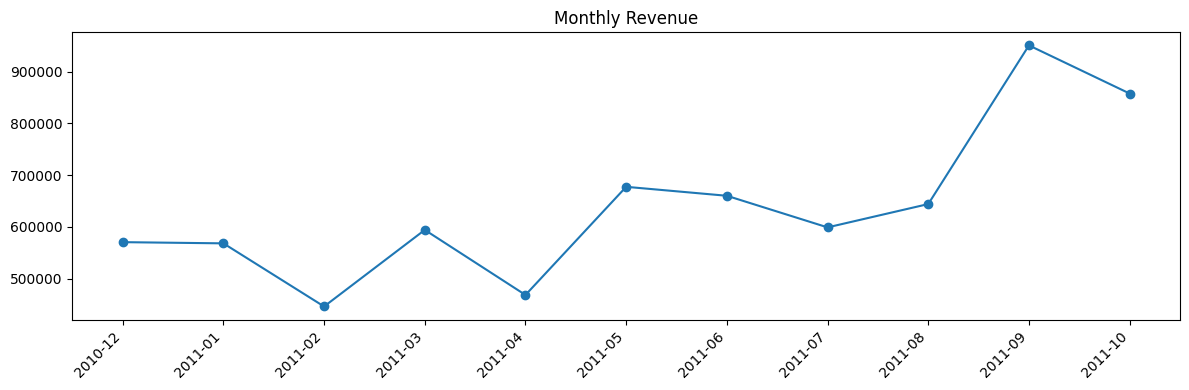

In [5]:
#  Monthly Revenue Trend
df['YearMonth'] = df['InvoiceDate'].dt.to_period('M')
monthly = df.groupby('YearMonth')['TotalPrice'].sum().reset_index()
monthly['YearMonth'] = monthly['YearMonth'].astype(str)

plt.figure(figsize=(12, 4))
plt.plot(monthly['YearMonth'], monthly['TotalPrice'], marker='o')
plt.xticks(rotation=45, ha='right')
plt.title('Monthly Revenue')
plt.tight_layout()
plt.savefig('monthly_revenue.png', dpi=100)
plt.show()

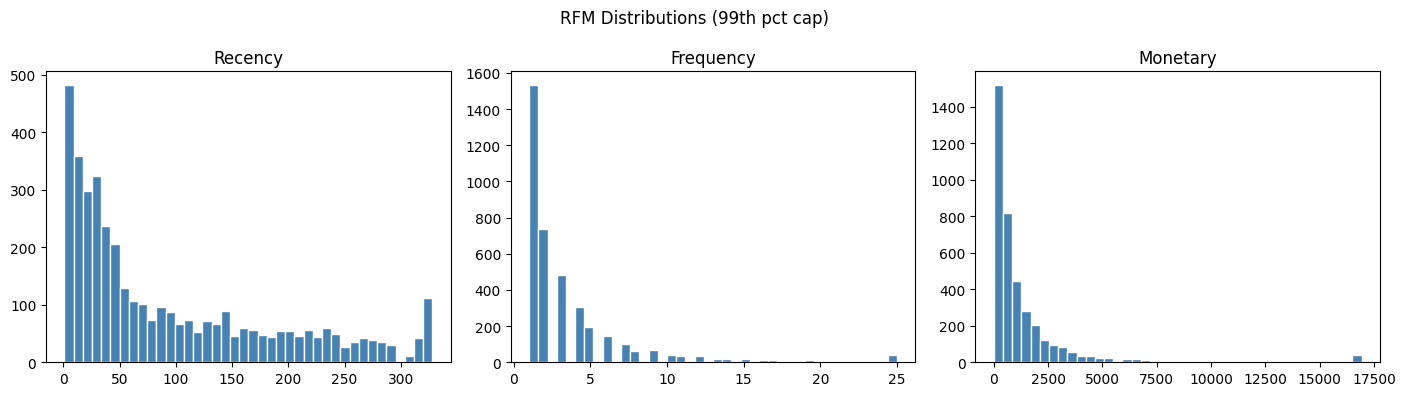

In [6]:
#  RFM Distributions
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, ['Recency', 'Frequency', 'Monetary']):
    data = rfm[col].clip(upper=rfm[col].quantile(0.99))
    ax.hist(data, bins=40, color='steelblue', edgecolor='white')
    ax.set_title(col)
plt.suptitle('RFM Distributions (99th pct cap)')
plt.tight_layout()
plt.savefig('rfm_distributions.png', dpi=100)
plt.show()

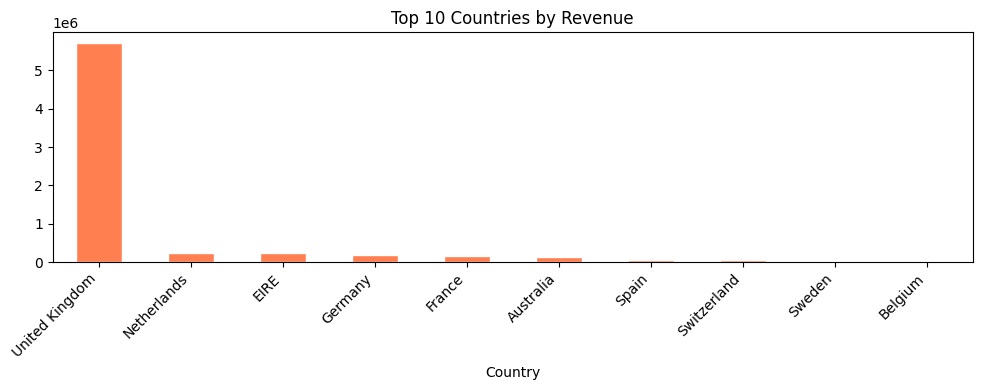

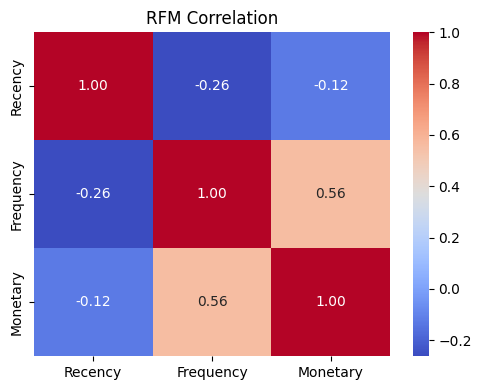

In [7]:
#  Top 10 Countries by Revenue
top_countries = (df.groupby('Country')['TotalPrice']
                   .sum()
                   .sort_values(ascending=False)
                   .head(10))

plt.figure(figsize=(10, 4))
top_countries.plot(kind='bar', color='coral', edgecolor='white')
plt.title('Top 10 Countries by Revenue')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('top_countries.png', dpi=100)
plt.show()

#  Correlation heatmap
plt.figure(figsize=(5, 4))
sns.heatmap(rfm[['Recency','Frequency','Monetary']].corr(),
            annot=True, fmt='.2f', cmap='coolwarm')
plt.title('RFM Correlation')
plt.tight_layout()
plt.savefig('rfm_corr.png', dpi=100)
plt.show()

In [9]:
#  Save RFM table
rfm.to_csv('rfm_table.csv', index=False)
print('Saved as rfm_table.csv')

Saved as rfm_table.csv
